# LINEAR REGRESSION & MULTIPLE LINEAR REGRESSION IMPLEMENTATION

**Name:** Sumit Mund **SIC:** 24BCSH05 **Roll No.:** 15  
**Topic:** Simple Linear Regression (SLR) and Multiple Linear Regression (MLR) Implementation



## SIMPLE LINEAR REGRESSION FROM SCRATCH (LEAST SQUARES)

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data set (obs, x, y)
df = pd.DataFrame({
    "obs": [1, 2, 3, 4, 5],
    "x":   [5, 7, 10, 12, 20],
    "y":   [10, 20, 30, 40, 50]
})
print("\n Dataframe Info")
df.info()

train_data = df.iloc[:, 1:-1].values
y = df.iloc[:, -1].values
test_point = [15]

print("\n Split Data Shapes ")
print(f"Train data shape: {train_data.shape}")
print(f"Labels shape: {y.shape}")
print(f"Test point: {test_point}")


 Dataframe Info
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   obs     5 non-null      int64
 1   x       5 non-null      int64
 2   y       5 non-null      int64
dtypes: int64(3)
memory usage: 252.0 bytes

 Split Data Shapes 
Train data shape: (5, 1)
Labels shape: (5,)
Test point: [15]


In [2]:
def simpleLinearRegression(train_data, train_labels):
    x = train_data[:, 0]

    # Means
    x_mean = np.mean(x)
    y_mean = np.mean(train_labels)
    print(f"x_mean: {x_mean}")
    print(f"y_mean: {y_mean}")

    # Deviations from the mean
    dx = x - x_mean
    dy = train_labels - y_mean

    steps = pd.DataFrame({
        "x": x,
        "y": train_labels,
        "x - x_mean": dx,
        "y - y_mean": dy,
        "(x - x_mean)(y - y_mean)": dx * dy,
        "(x - x_mean)^2": dx ** 2
    })
    print("\nCalculation Table:")
    print(steps.round(2) + 0.0)

    # Sums
    Sxy = np.sum(dx * dy)
    Sxx = np.sum(dx ** 2)
    print(f"\nSum of (x - x_mean)(y - y_mean): {Sxy}")
    print(f"Sum of (x - x_mean)^2: {Sxx}")

    # Slope and intercept
    b1 = Sxy / Sxx
    b0 = y_mean - b1 * x_mean
    print(f"\nB1 (slope): {b1}")
    print(f"B0 (intercept): {b0}")

    return b0, b1

In [3]:
def predictSLR(x, b0, b1):
    return b0 + b1 * x

# test it
b0, b1 = simpleLinearRegression(train_data, y)
print(f"\nRegression Line: y = {b0:.4f} + {b1:.4f} * x")

predicted_value = predictSLR(test_point[0], b0, b1)
print(f"\nPredicted y for x = {test_point[0]}: {predicted_value}")

x_mean: 10.8
y_mean: 30.0

Calculation Table:
      x     y  x - x_mean  y - y_mean  (x - x_mean)(y - y_mean)  \
0   5.0  10.0        -5.8       -20.0                     116.0   
1   7.0  20.0        -3.8       -10.0                      38.0   
2  10.0  30.0        -0.8         0.0                       0.0   
3  12.0  40.0         1.2        10.0                      12.0   
4  20.0  50.0         9.2        20.0                     184.0   

   (x - x_mean)^2  
0           33.64  
1           14.44  
2            0.64  
3            1.44  
4           84.64  

Sum of (x - x_mean)(y - y_mean): 350.0
Sum of (x - x_mean)^2: 134.8

B1 (slope): 2.5964391691394657
B0 (intercept): 1.9584569732937673

Regression Line: y = 1.9585 + 2.5964 * x

Predicted y for x = 15: 40.90504451038575


### Model Evaluation (RSS, MSE, R²)


In [4]:
def evaluate(y_true, y_pred):
    rss = np.sum((y_true - y_pred) ** 2)
    tss = np.sum((y_true - np.mean(y_true)) ** 2)
    mse = rss / len(y_true)
    r2 = 1 - rss / tss
    return rss, mse, r2

y_hat = predictSLR(train_data[:, 0], b0, b1)
rss, mse, r2 = evaluate(y, y_hat)

print("Actual   :", y)
print("Predicted:", np.round(y_hat, 3))
print("Residuals:", np.round(y - y_hat, 3))
print(f"\nRSS: {rss:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R2 : {r2:.4f}")

Actual   : [10 20 30 40 50]
Predicted: [14.941 20.134 27.923 33.116 53.887]
Residuals: [-4.941 -0.134  2.077  6.884 -3.887]

RSS: 91.2463
MSE: 18.2493
R2 : 0.9088


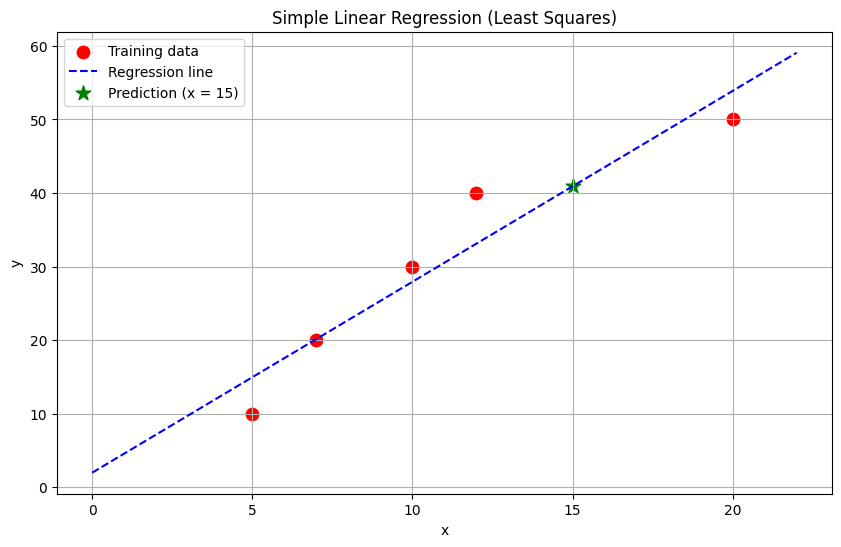

In [5]:
# plotting the regression line
plt.figure(figsize=(10, 6))
plt.scatter(train_data[:, 0], y, color='red', s=80, label='Training data')
line_x = np.linspace(0, 22, 100)
plt.plot(line_x, predictSLR(line_x, b0, b1), color='blue', linestyle='dashed', label='Regression line')
plt.scatter(test_point[0], predicted_value, color='green', s=120, marker='*', label='Prediction (x = 15)')
plt.title("Simple Linear Regression (Least Squares)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

## SIMPLE LINEAR REGRESSION FROM SCRATCH (GRADIENT DESCENT)


In [6]:
def gradientDescentSLR(x, y, alpha, epochs):
    w0, w1 = 0.0, 0.0            # start from zero
    loss_history = []

    for epoch in range(epochs):
        # Forward pass
        y_hat = w0 + w1 * x
        error = y - y_hat

        # Loss (MSE)
        loss = np.mean(error ** 2)
        loss_history.append(loss)

        # Gradients
        dw0 = -2 * np.mean(error)
        dw1 = -2 * np.mean(x * error)

        # Update both weights together
        w0 = w0 - alpha * dw0
        w1 = w1 - alpha * dw1

        if epoch % 1000 == 0:
            print(f"Epoch {epoch}: Loss = {loss:.6f}, B0 = {w0:.6f}, B1 = {w1:.6f}")

    return w0, w1, loss_history

In [7]:
# test it
alpha = 0.005
epochs = 10000
gd_b0, gd_b1, loss_history = gradientDescentSLR(train_data[:, 0].astype(float), y.astype(float), alpha, epochs)

print(f"\nGradient Descent  -> B0: {gd_b0:.6f}, B1: {gd_b1:.6f}")
print(f"Least Squares     -> B0: {b0:.6f}, B1: {b1:.6f}")
print(f"\nPredicted y for x = {test_point[0]}: {gd_b0 + gd_b1 * test_point[0]}")

Epoch 0: Loss = 1100.000000, B0 = 0.300000, B1 = 3.940000
Epoch 1000: Loss = 18.263001, B0 = 1.688409, B1 = 2.616776
Epoch 2000: Loss = 18.249586, B0 = 1.916778, B1 = 2.599578
Epoch 3000: Loss = 18.249266, B0 = 1.952024, B1 = 2.596924
Epoch 4000: Loss = 18.249258, B0 = 1.957464, B1 = 2.596514


Epoch 5000: Loss = 18.249258, B0 = 1.958304, B1 = 2.596451


Epoch 6000: Loss = 18.249258, B0 = 1.958433, B1 = 2.596441


Epoch 7000: Loss = 18.249258, B0 = 1.958453, B1 = 2.596439
Epoch 8000: Loss = 18.249258, B0 = 1.958456, B1 = 2.596439
Epoch 9000: Loss = 18.249258, B0 = 1.958457, B1 = 2.596439

Gradient Descent  -> B0: 1.958457, B1: 2.596439
Least Squares     -> B0: 1.958457, B1: 2.596439

Predicted y for x = 15: 40.90504451212807


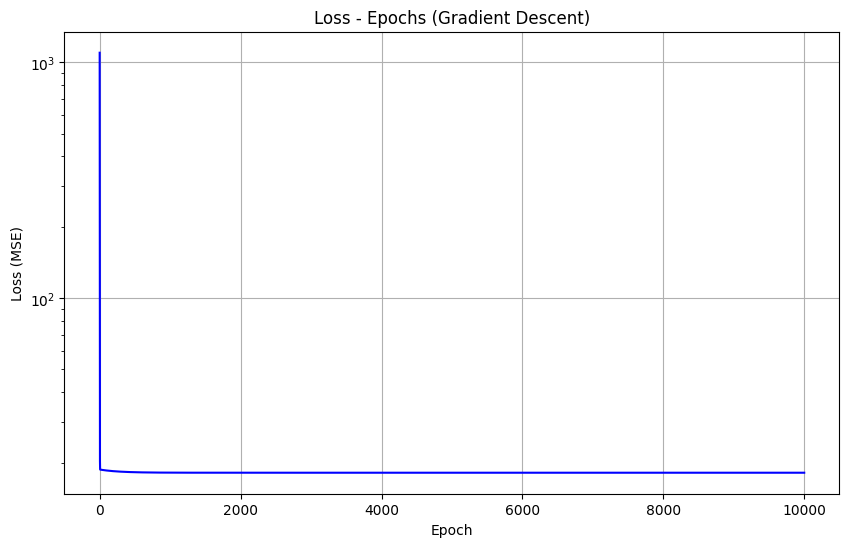

In [8]:
# plotting the loss
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), loss_history, color='blue')
plt.yscale('log')
plt.title("Loss - Epochs (Gradient Descent)")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.show()

## SIMPLE LINEAR REGRESSION WITH SK-LEARN

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df[["x"]].values          # sklearn needs a 2D feature array
y = df["y"].values

model = LinearRegression()

# Train the model
model.fit(X, y)

# Predict
y_pred = model.predict(X)
new_pred = model.predict([[15]])

print(f"Intercept (B0): {model.intercept_}")
print(f"Coefficient (B1): {model.coef_[0]}")
print(f"\nPredicted y for x = 15: {new_pred[0]}")
print(f"\nMSE: {mean_squared_error(y, y_pred):.4f}")
print(f"R2 : {r2_score(y, y_pred):.4f}")

Intercept (B0): 1.9584569732937638
Coefficient (B1): 2.596439169139466

Predicted y for x = 15: 40.90504451038576

MSE: 18.2493
R2 : 0.9088


In [10]:
# Comparison of the three methods
comparison = pd.DataFrame({
    "Method": ["Least Squares (scratch)", "Gradient Descent (scratch)", "sklearn LinearRegression"],
    "B0": [b0, gd_b0, model.intercept_],
    "B1": [b1, gd_b1, model.coef_[0]],
})
print(comparison.round(6).to_string(index=False))

                    Method       B0       B1
   Least Squares (scratch) 1.958457 2.596439
Gradient Descent (scratch) 1.958457 2.596439
  sklearn LinearRegression 1.958457 2.596439


## MULTIPLE LINEAR REGRESSION FROM SCRATCH



In [11]:
# Data set (obs, x1, x2, x3, y)
df_mlr = pd.DataFrame({
    "obs":        [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "hours":      [2, 4, 5, 6, 3, 8, 7, 1, 9, 5],
    "prev_score": [55, 60, 70, 65, 50, 80, 75, 45, 85, 62],
    "sleep":      [6, 7, 6, 8, 5, 7, 8, 5, 6, 7],
    "score":      [47.0, 57.1, 61.5, 64.2, 45.6, 74.5, 73.1, 41.2, 79.0, 59.1]
})
print("\n Dataframe Info")
df_mlr.info()

train_data = df_mlr.iloc[:, 1:-1].values
y = df_mlr.iloc[:, -1].values
test_point = [6, 68, 7]

print("\n Split Data Shapes ")
print(f"Train data shape: {train_data.shape}")
print(f"Labels shape: {y.shape}")
print(f"Test point: {test_point}")


 Dataframe Info
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   obs         10 non-null     int64  
 1   hours       10 non-null     int64  
 2   prev_score  10 non-null     int64  
 3   sleep       10 non-null     int64  
 4   score       10 non-null     float64
dtypes: float64(1), int64(4)
memory usage: 532.0 bytes

 Split Data Shapes 
Train data shape: (10, 3)
Labels shape: (10,)
Test point: [6, 68, 7]


In [12]:
def multipleLinearRegression(train_data, train_labels):
    n = train_data.shape[0]

    # Add a column of ones for the intercept (B0)
    X = np.c_[np.ones(n), train_data]
    print(f"X (with bias column) shape: {X.shape}")

    # Normal equation pieces
    XtX = X.T @ X
    Xty = X.T @ train_labels
    print("\nX^T X:")
    print(XtX)
    print("\nX^T y:")
    print(Xty)

    XtX_inv = np.linalg.inv(XtX)
    print("\n(X^T X)^-1:")
    print(np.round(XtX_inv, 4))

    # beta = (X^T X)^-1 X^T y
    beta = XtX_inv @ Xty
    print("\nBeta (B0, B1, ..., Bp):")
    print(beta)

    return beta

In [13]:
def predictMLR(point, beta):
    return beta[0] + np.dot(beta[1:], point)

# test it
beta = multipleLinearRegression(train_data, y)

print(f"\nRegression Equation:")
print(f"score = {beta[0]:.4f} + {beta[1]:.4f}*hours + {beta[2]:.4f}*prev_score + {beta[3]:.4f}*sleep")

predicted_value = predictMLR(test_point, beta)
print(f"\nPredicted score for {test_point}: {predicted_value}")

X (with bias column) shape: (10, 4)

X^T X:
[[1.0000e+01 5.0000e+01 6.4700e+02 6.5000e+01]
 [5.0000e+01 3.1000e+02 3.5250e+03 3.3900e+02]
 [6.4700e+02 3.5250e+03 4.3369e+04 4.2690e+03]
 [6.5000e+01 3.3900e+02 4.2690e+03 4.3300e+02]]

X^T y:
[  602.3  3307.3 40444.7  3992.3]

(X^T X)^-1:
[[ 2.27263e+01  2.17090e+00 -4.19200e-01 -9.78800e-01]
 [ 2.17090e+00  2.61400e-01 -4.78000e-02 -5.98000e-02]
 [-4.19200e-01 -4.78000e-02  9.60000e-03  5.50000e-03]
 [-9.78800e-01 -5.98000e-02  5.50000e-03  1.41400e-01]]

Beta (B0, B1, ..., Bp):
[8.06627095 2.22651759 0.49011659 1.43393813]

Regression Equation:
score = 8.0663 + 2.2265*hours + 0.4901*prev_score + 1.4339*sleep

Predicted score for [6, 68, 7]: 64.79087139869961


### Model Evaluation (RSS, MSE, R², Adjusted R²)

$$R^2_{adj} = 1 - (1 - R^2)\frac{N - 1}{N - p - 1}$$

In [14]:
n, p = train_data.shape
y_hat = np.array([predictMLR(row, beta) for row in train_data])

rss, mse, r2 = evaluate(y, y_hat)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Actual   :", y)
print("Predicted:", np.round(y_hat, 2))
print("Residuals:", np.round(y - y_hat, 2))
print(f"\nRSS         : {rss:.4f}")
print(f"MSE         : {mse:.4f}")
print(f"R2          : {r2:.4f}")
print(f"Adjusted R2 : {adj_r2:.4f}")

Actual   : [47.  57.1 61.5 64.2 45.6 74.5 73.1 41.2 79.  59.1]
Predicted: [48.08 56.42 62.11 64.75 46.42 75.13 71.88 39.52 78.37 59.62]
Residuals: [-1.08  0.68 -0.61 -0.55 -0.82 -0.63  1.22  1.68  0.63 -0.52]

RSS         : 8.3638
MSE         : 0.8364
R2          : 0.9944
Adjusted R2 : 0.9916


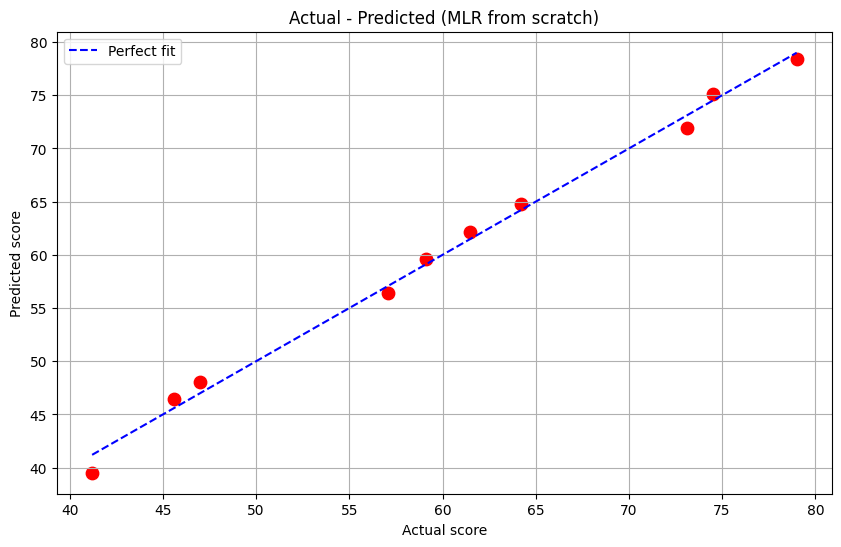

In [15]:
# Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y, y_hat, color='red', s=80)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='blue', linestyle='dashed', label='Perfect fit')
plt.title("Actual - Predicted (MLR from scratch)")
plt.xlabel("Actual score")
plt.ylabel("Predicted score")
plt.legend()
plt.grid(True)
plt.show()

### MLR USING GRADIENT DESCENT (FROM SCRATCH)


In [16]:
def gradientDescentMLR(train_data, train_labels, alpha, epochs):
    n = train_data.shape[0]

    # Standardise features
    mean = train_data.mean(axis=0)
    std = train_data.std(axis=0)
    Z = (train_data - mean) / std
    Zb = np.c_[np.ones(n), Z]

    w = np.zeros(Zb.shape[1])
    loss_history = []

    for epoch in range(epochs):
        error = train_labels - Zb @ w
        loss = np.mean(error ** 2)
        loss_history.append(loss)

        grad = -(2 / n) * (Zb.T @ error)
        w = w - alpha * grad

        if epoch % 200 == 0:
            print(f"Epoch {epoch}: Loss = {loss:.6f}")

    # Convert weights back to the original feature scale
    beta = np.zeros_like(w)
    beta[1:] = w[1:] / std
    beta[0] = w[0] - np.sum(w[1:] * mean / std)

    return beta, loss_history

In [17]:
# test it
gd_beta, mlr_loss = gradientDescentMLR(train_data.astype(float), y, alpha=0.1, epochs=1000)

print("\nGradient Descent Beta:", gd_beta)
print("Normal Equation Beta :", beta)
print(f"\nPredicted score for {test_point}: {predictMLR(test_point, gd_beta)}")

Epoch 0: Loss = 3777.777000
Epoch 200: Loss = 0.836589
Epoch 400: Loss = 0.836395
Epoch 600: Loss = 0.836382
Epoch 800: Loss = 0.836381

Gradient Descent Beta: [8.06713464 2.22661853 0.49009731 1.4339195 ]
Normal Equation Beta : [8.06627095 2.22651759 0.49011659 1.43393813]

Predicted score for [6, 68, 7]: 64.79089940558768


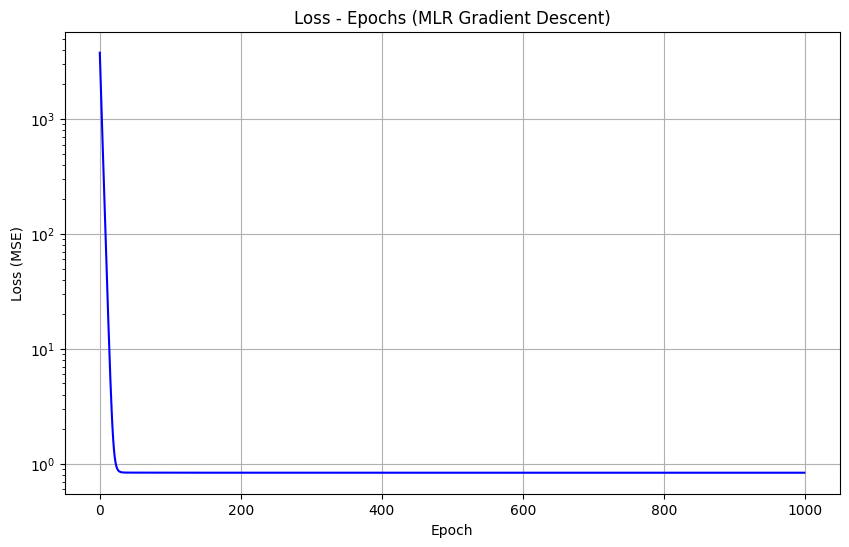

In [18]:
# plotting the loss
plt.figure(figsize=(10, 6))
plt.plot(range(len(mlr_loss)), mlr_loss, color='blue')
plt.yscale('log')
plt.title("Loss - Epochs (MLR Gradient Descent)")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.show()

## MULTIPLE LINEAR REGRESSION WITH SK-LEARN

In [19]:
X = df_mlr[["hours", "prev_score", "sleep"]].values
y = df_mlr["score"].values

model_mlr = LinearRegression()

# Train the model
model_mlr.fit(X, y)

# Predict
y_pred = model_mlr.predict(X)
new_pred = model_mlr.predict([test_point])

print(f"Intercept (B0): {model_mlr.intercept_}")
print(f"Coefficients (B1, B2, B3): {model_mlr.coef_}")
print(f"\nPredicted score for {test_point}: {new_pred[0]}")
print(f"\nMSE: {mean_squared_error(y, y_pred):.4f}")
print(f"R2 : {r2_score(y, y_pred):.4f}")

Intercept (B0): 8.066270952195303
Coefficients (B1, B2, B3): [2.22651759 0.49011659 1.43393813]

Predicted score for [6, 68, 7]: 64.79087139870302

MSE: 0.8364
R2 : 0.9944


In [20]:
# Comparison of the methods
comparison = pd.DataFrame({
    "Coefficient": ["B0 (intercept)", "B1 (hours)", "B2 (prev_score)", "B3 (sleep)"],
    "Normal Equation": beta,
    "Gradient Descent": gd_beta,
    "sklearn": np.r_[model_mlr.intercept_, model_mlr.coef_],
})
print(comparison.round(6).to_string(index=False))

    Coefficient  Normal Equation  Gradient Descent  sklearn
 B0 (intercept)         8.066271          8.067135 8.066271
     B1 (hours)         2.226518          2.226619 2.226518
B2 (prev_score)         0.490117          0.490097 0.490117
     B3 (sleep)         1.433938          1.433919 1.433938

### MLR WITH SK-LEARN ON DIABETES DATA SET

- **Samples:** 442
- **Features:** 10 (age, sex, bmi, bp, s1 - s6, already mean-centred and scaled)
- **Target:** a quantitative measure of disease progression one year after baseline

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

diabetes = load_diabetes()
df_d = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df_d['target'] = diabetes.target
print(df_d.head())

print("\n Dataframe Info")
df_d.info()

In [22]:
# Separate features and labels
X = diabetes.data
y = diabetes.target

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape {X_train.shape} , testing_data shape {X_test.shape}")

Training data shape (353, 10) , testing_data shape (89, 10)


In [23]:
# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model_d = LinearRegression()

# Train the model
model_d.fit(X_train, y_train)

# Predict test data
y_pred = model_d.predict(X_test)

In [24]:
# Display predictions
print("\nActual Values (first 10):")
print(y_test[:10])

print("\nPredicted Values (first 10):")
print(np.round(y_pred[:10], 1))


Actual Values (first 10):
[219.  70. 202. 230. 111.  84. 242. 272.  94.  96.]

Predicted Values (first 10):
[139.5 179.5 134.  291.4 123.8  92.2 258.2 181.3  90.2 108.6]


In [25]:
from sklearn.metrics import mean_absolute_error

print(f"MAE : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE : {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R2  : {r2_score(y_test, y_pred):.4f}")

print("\nIntercept:", model_d.intercept_)
coef_table = pd.DataFrame({"feature": diabetes.feature_names, "coefficient": model_d.coef_})
print(coef_table.sort_values("coefficient", key=abs, ascending=False).to_string(index=False))

MAE : 42.7941
MSE : 2900.1936
RMSE: 53.8534
R2  : 0.4526

Intercept: 153.73654390934846
feature  coefficient
     s1   -44.448856
     s5    35.161195
    bmi    25.607121
     s2    24.640954
     bp    16.828872
     s4    13.138784
    sex   -11.511809
     s3     7.676978
     s6     2.351364
    age     1.753758


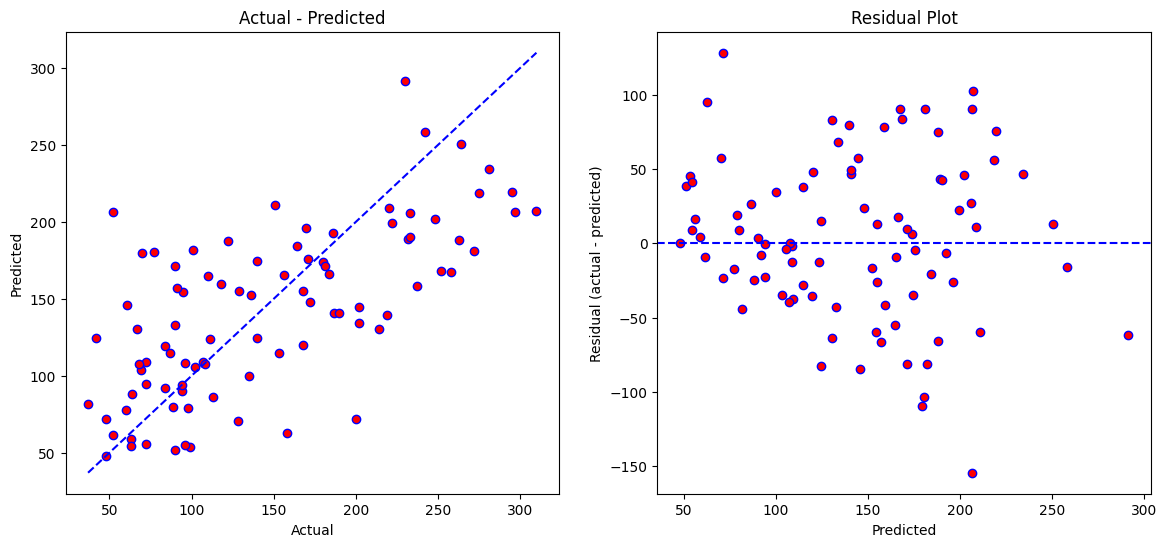

In [26]:
# plotting actual vs predicted and residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_pred, color='red', edgecolor='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='blue', linestyle='dashed')
axes[0].set_title("Actual - Predicted")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, color='red', edgecolor='blue')
axes[1].axhline(0, color='blue', linestyle='dashed')
axes[1].set_title("Residual Plot")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual (actual - predicted)")

plt.show()